# 06 — Enhanced 3D Visualization

This notebook uses **VPython**, **REBOUND**, and **Matplotlib** for rich 3D visualization of the three-body problem.

**Tools:**
1. **VPython** — real-time 3D animation in the browser (interactive)
2. **REBOUND** — professional N-body integrator with built-in visualization
3. **Matplotlib 3D** — static 3D trajectory plots

**Configurations:** Figure-eight, Lagrange triangle, Pythagorean (chaotic), and custom setups.

In [11]:
import sys; sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from src.core.initial_conditions import (
    figure_eight, lagrange_triangle, pythagorean,
    hierarchical_solar_system, build_state_vector, CATALOGUE
)
from src.core.integrator import integrate_scipy, integrate_leapfrog
from src.core.equations import transform_to_cm_frame, G_UNITS

print('✓ Core imports successful')

✓ Core imports successful


---
## 1. REBOUND — Professional N-Body Simulation

REBOUND is a multi-purpose N-body integrator used in planetary dynamics research. It includes:
- **WHFast** symplectic integrator (designed for planetary systems)
- **IAS15** 15th-order adaptive integrator (machine precision)
- Built-in orbital element computation and visualization

We'll set up the figure-eight and compare REBOUND's IAS15 integrator with our custom RK4.

In [12]:
import rebound

def setup_rebound_sim(ic_func, integrator='ias15'):
    """Create a REBOUND simulation from our initial condition functions."""
    ic = ic_func()
    sim = rebound.Simulation()
    sim.G = G_UNITS
    sim.integrator = integrator
    sim.dt = 0.001

    # Transform to CM frame
    r1, r2, r3, v1, v2, v3 = transform_to_cm_frame(
        ic['r1'], ic['r2'], ic['r3'],
        ic['v1'], ic['v2'], ic['v3'],
        ic['m1'], ic['m2'], ic['m3']
    )

    # Add particles (REBOUND uses 3D, we set z=0)
    sim.add(m=ic['m1'], x=r1[0], y=r1[1], z=0, vx=v1[0], vy=v1[1], vz=0)
    sim.add(m=ic['m2'], x=r2[0], y=r2[1], z=0, vx=v2[0], vy=v2[1], vz=0)
    sim.add(m=ic['m3'], x=r3[0], y=r3[1], z=0, vx=v3[0], vy=v3[1], vz=0)
    sim.move_to_com()

    return sim, ic

# Figure-Eight with REBOUND's IAS15 (15th-order, machine precision)
sim_rb, ic = setup_rebound_sim(figure_eight, 'ias15')

# Integrate and store positions
N = 5000
t_end = ic['t_end']
times = np.linspace(0, t_end, N)
positions = np.zeros((N, 3, 3))  # (timesteps, bodies, xyz)

E0 = sim_rb.energy()
energies = np.zeros(N)

for i, t in enumerate(times):
    sim_rb.integrate(t)
    for j in range(3):
        p = sim_rb.particles[j]
        positions[i, j] = [p.x, p.y, p.z]
    energies[i] = sim_rb.energy()

energy_err = np.abs((energies - E0) / E0)
print(f'REBOUND IAS15 — Figure-Eight')
print(f'  Max ΔE/E₀: {energy_err.max():.2e}')
print(f'  Duration : {t_end} yr, Steps: {N}')

REBOUND IAS15 — Figure-Eight
  Max ΔE/E₀: 3.59e-10
  Duration : 20.0 yr, Steps: 5000


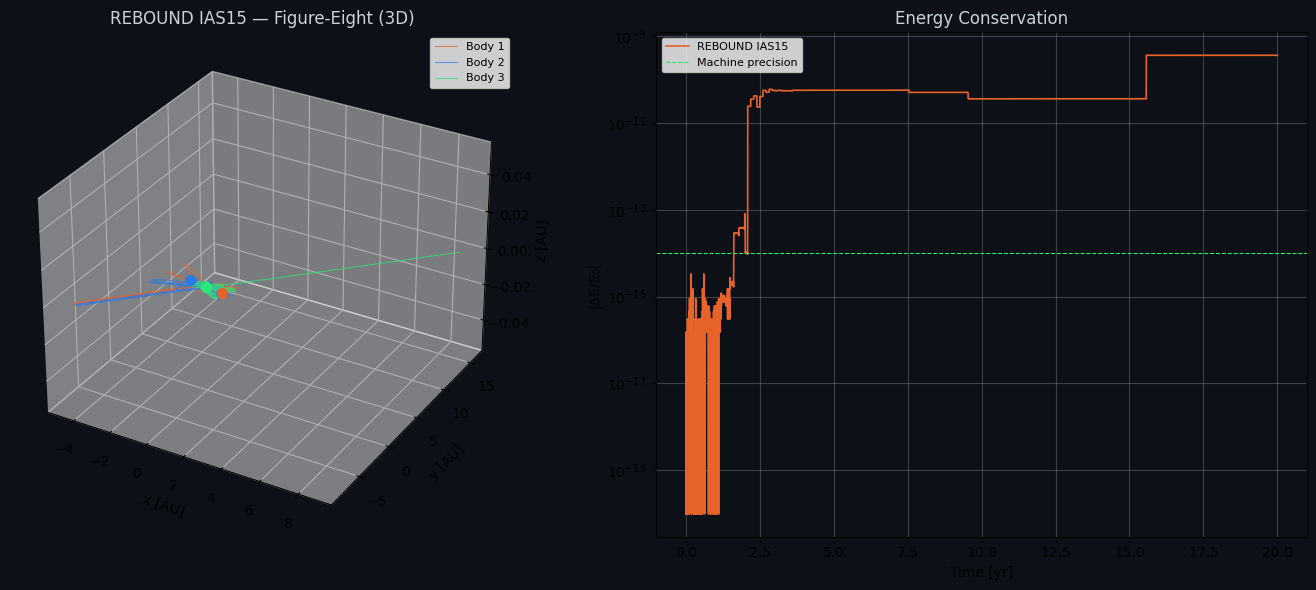

In [13]:
# 3D trajectory plot from REBOUND data
COLORS = ['#E8632A', '#2A7AE8', '#2AE87A']
LABELS = ['Body 1', 'Body 2', 'Body 3']

fig = plt.figure(figsize=(14, 6))

# 3D view
ax1 = fig.add_subplot(121, projection='3d', facecolor='#0D1117')
for b in range(3):
    ax1.plot(positions[:, b, 0], positions[:, b, 1], positions[:, b, 2],
             color=COLORS[b], alpha=0.7, lw=0.8, label=LABELS[b])
    ax1.scatter(*positions[0, b], color=COLORS[b], s=50, zorder=5)
ax1.set_xlabel('x [AU]'); ax1.set_ylabel('y [AU]'); ax1.set_zlabel('z [AU]')
ax1.set_title('REBOUND IAS15 — Figure-Eight (3D)', color='#C9D1D9')
ax1.legend(fontsize=8)
ax1.set_facecolor('#0D1117')

# Energy conservation comparison
ax2 = fig.add_subplot(122, facecolor='#0D1117')
ax2.semilogy(times, energy_err + 1e-20, color='#E8632A', lw=1.2, label='REBOUND IAS15')
ax2.axhline(1e-14, color='#2AE87A', ls='--', lw=0.8, label='Machine precision')
ax2.set_xlabel('Time [yr]'); ax2.set_ylabel('|ΔE/E₀|')
ax2.set_title('Energy Conservation', color='#C9D1D9')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

fig.patch.set_facecolor('#0D1117')
fig.tight_layout()
plt.show()

### 1.2 REBOUND — All Configurations Compared

Run all preset configurations through REBOUND and plot their 3D trajectories.

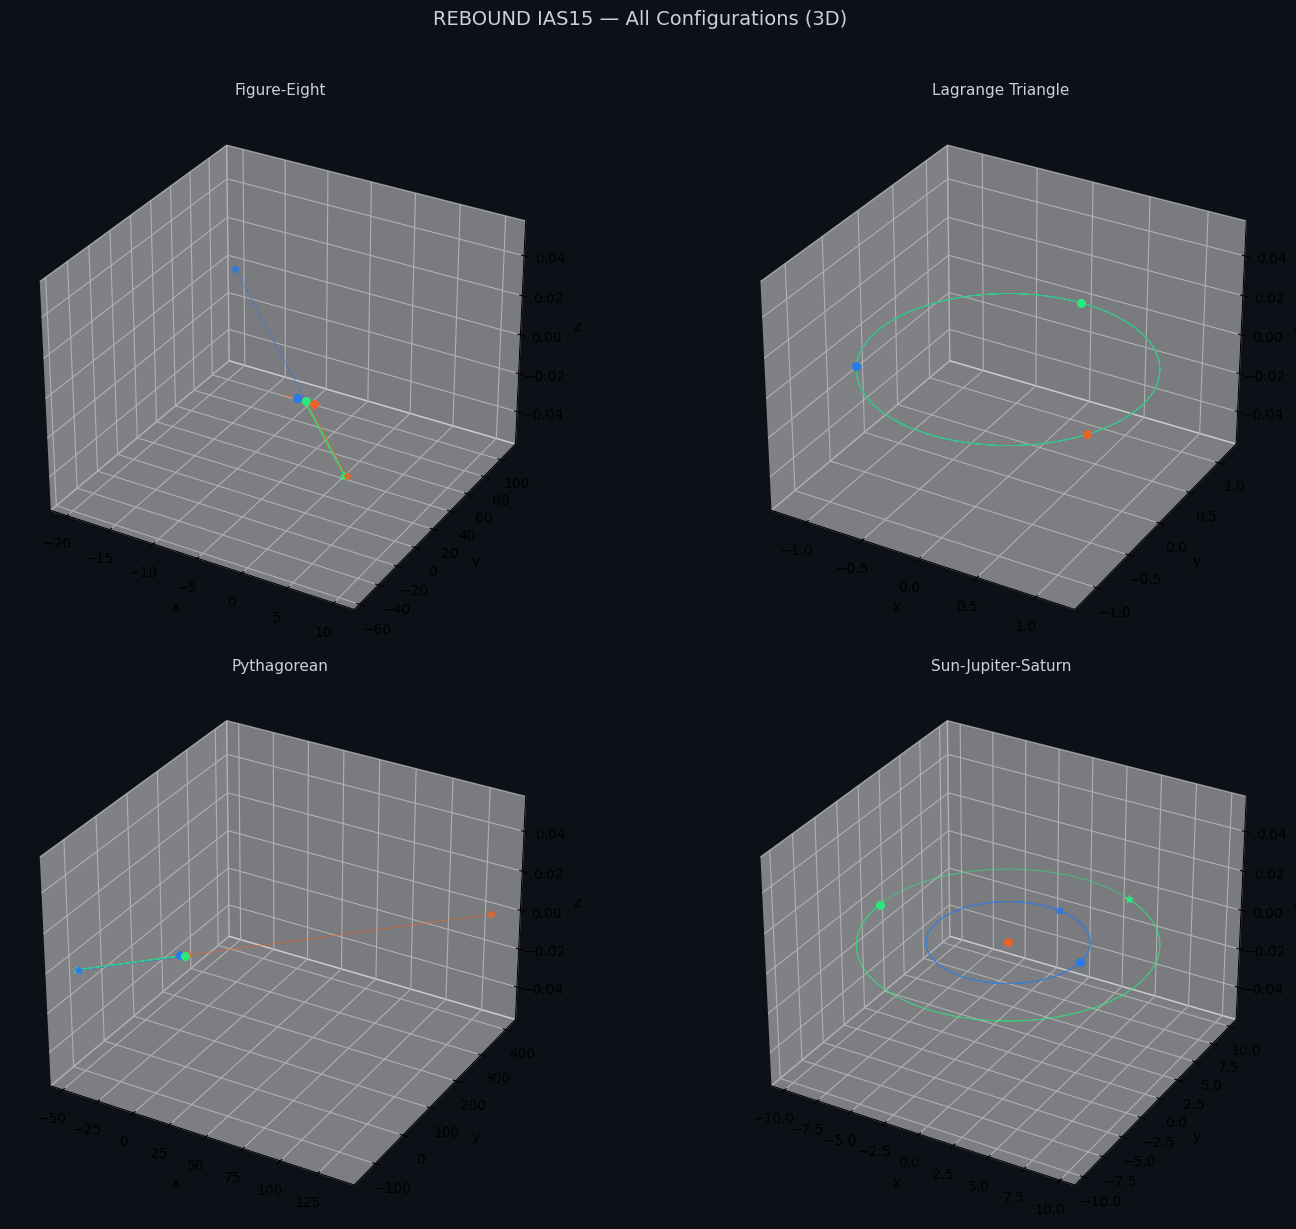

In [14]:
configs = {
    'Figure-Eight': figure_eight,
    'Lagrange Triangle': lagrange_triangle,
    'Pythagorean': pythagorean,
    'Sun-Jupiter-Saturn': hierarchical_solar_system,
}

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#0D1117')

for idx, (name, ic_func) in enumerate(configs.items()):
    sim_rb, ic = setup_rebound_sim(ic_func, 'ias15')
    N = 3000
    t_end = min(ic['t_end'], 50)
    ts = np.linspace(0, t_end, N)
    pos = np.zeros((N, 3, 3))

    for i, t in enumerate(ts):
        sim_rb.integrate(t)
        for j in range(3):
            p = sim_rb.particles[j]
            pos[i, j] = [p.x, p.y, p.z]

    ax = fig.add_subplot(2, 2, idx+1, projection='3d', facecolor='#0D1117')
    for b in range(3):
        ax.plot(pos[:, b, 0], pos[:, b, 1], pos[:, b, 2],
                color=COLORS[b], alpha=0.7, lw=0.6)
        ax.scatter(*pos[0, b], color=COLORS[b], s=30, zorder=5)
        ax.scatter(*pos[-1, b], color=COLORS[b], s=30, marker='*', zorder=5)
    ax.set_title(name, color='#C9D1D9', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_facecolor('#0D1117')

fig.suptitle('REBOUND IAS15 — All Configurations (3D)', color='#C9D1D9', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 2. VPython — Interactive 3D Animation

VPython provides real-time 3D graphics directly in the Jupyter notebook.
- Rotate the scene by dragging with the right mouse button
- Zoom with the scroll wheel
- The simulation runs in real-time with glowing spheres and fading trails

In [15]:
from vpython import sphere, vector, color, rate, curve, canvas, label, mag

def run_vpython_simulation(ic_func, steps=8000, dt=0.001, trail_retain=600):
    """Run an interactive VPython 3D simulation."""
    ic = ic_func()
    r1, r2, r3, v1, v2, v3 = transform_to_cm_frame(
        ic['r1'], ic['r2'], ic['r3'],
        ic['v1'], ic['v2'], ic['v3'],
        ic['m1'], ic['m2'], ic['m3']
    )
    masses = [ic['m1'], ic['m2'], ic['m3']]

    # Canvas
    scene = canvas(title=f'<b>{ic["name"]}</b><br><i>{ic["description"][:80]}...</i>',
                   width=900, height=550,
                   background=vector(0.05, 0.07, 0.09),
                   center=vector(0, 0, 0))

    # Body colors
    body_colors = [color.orange, vector(0.16, 0.48, 0.91), color.green]
    body_names = ['Body 1', 'Body 2', 'Body 3']
    positions = [r1, r2, r3]
    velocities = [v1, v2, v3]

    # Create spheres with trails
    radius = 0.08
    bodies = []
    trails = []
    for i in range(3):
        r = positions[i]
        s = sphere(pos=vector(r[0], r[1], 0), radius=radius * (1 + 0.3 * np.log(1 + masses[i])),
                   color=body_colors[i], emissive=True,
                   make_trail=True, trail_type='curve',
                   trail_color=body_colors[i], retain=trail_retain)
        bodies.append(s)

    # Time label
    time_label = label(pos=vector(0, 0, 0), text='t = 0.00 yr',
                       height=14, color=color.white, opacity=0,
                       pixel_pos=True, align='left',
                       xoffset=20, yoffset=20)

    # State arrays
    rs = [np.array([r[0], r[1]], dtype=float) for r in positions]
    vs = [np.array([v[0], v[1]], dtype=float) for v in velocities]
    G = G_UNITS
    SOFT = 1e-4
    t = 0.0

    # RK4 integration loop
    for step in range(steps):
        rate(500)  # max 500 iterations/sec

        # Build state vector
        state = np.concatenate(rs + vs)

        # RK4 step
        def deriv(s):
            p = [s[0:2], s[2:4], s[4:6]]
            v = [s[6:8], s[8:10], s[10:12]]
            acc = [np.zeros(2) for _ in range(3)]
            for i in range(3):
                for j in range(3):
                    if i == j: continue
                    rij = p[j] - p[i]
                    dist = (np.dot(rij, rij) + SOFT**2) ** 1.5
                    acc[i] += G * masses[j] * rij / dist
            return np.concatenate(v + acc)

        k1 = deriv(state)
        k2 = deriv(state + 0.5 * dt * k1)
        k3 = deriv(state + 0.5 * dt * k2)
        k4 = deriv(state + dt * k3)
        state = state + dt / 6 * (k1 + 2*k2 + 2*k3 + k4)

        rs = [state[0:2], state[2:4], state[4:6]]
        vs = [state[6:8], state[8:10], state[10:12]]
        t += dt

        # Update VPython objects
        for i in range(3):
            bodies[i].pos = vector(rs[i][0], rs[i][1], 0)

        if step % 50 == 0:
            time_label.text = f't = {t:.2f} yr'

    return scene

print('VPython simulation ready. Run the next cell to launch.')

ModuleNotFoundError: No module named 'pkg_resources'

In [ ]:
# === Figure-Eight Choreography ===
# This will open an interactive 3D window in the notebook.
# Right-click drag to rotate, scroll to zoom.
run_vpython_simulation(figure_eight, steps=6000, dt=0.001)

In [ ]:
# === Pythagorean Problem (Chaotic) ===
# Watch the lightest body get ejected!
run_vpython_simulation(pythagorean, steps=15000, dt=0.001, trail_retain=1500)

In [ ]:
# === Lagrange Triangle ===
# Rigid rotation — the triangle maintains its shape.
run_vpython_simulation(lagrange_triangle, steps=8000, dt=0.001)

---
## 3. Integrator Accuracy — REBOUND vs Custom

Compare energy conservation between:
- **REBOUND IAS15** (15th-order, machine precision)
- **Our Leapfrog** (2nd-order, symplectic)
- **Our RK4** (4th-order, non-symplectic)

In [ ]:
# Run figure-eight with all integrators
ic = figure_eight()
r1, r2, r3, v1, v2, v3 = transform_to_cm_frame(
    ic['r1'], ic['r2'], ic['r3'], ic['v1'], ic['v2'], ic['v3'],
    ic['m1'], ic['m2'], ic['m3']
)
ic_cm = dict(ic)
ic_cm.update({'r1':r1,'r2':r2,'r3':r3,'v1':v1,'v2':v2,'v3':v3})
y0 = build_state_vector(ic_cm)
masses = np.array([ic['m1'], ic['m2'], ic['m3']])
t_end = 20.0
t_eval = np.linspace(0, t_end, 5000)

# Our integrators
res_dop = integrate_scipy(y0, masses, (0, t_end), t_eval, method='DOP853', rtol=1e-12, atol=1e-14)
res_lf = integrate_leapfrog(y0, masses, (0, t_end), dt=0.001)

# REBOUND
sim_rb, _ = setup_rebound_sim(figure_eight, 'ias15')
E0_rb = sim_rb.energy()
rb_times, rb_errors = [], []
for t in t_eval:
    sim_rb.integrate(t)
    rb_times.append(t)
    rb_errors.append(abs((sim_rb.energy() - E0_rb) / E0_rb))

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

ax.semilogy(rb_times, np.array(rb_errors) + 1e-20, color='#FFD700', lw=1.5, label='REBOUND IAS15')
ax.semilogy(res_dop.t, res_dop.energy_error + 1e-20, color='#2AE87A', lw=1.2, label='Our DOP853')
ax.semilogy(res_lf.t, res_lf.energy_error + 1e-20, color='#2A7AE8', lw=1.2, label='Our Leapfrog')

ax.set_xlabel('Time [yr]', color='#C9D1D9')
ax.set_ylabel('|ΔE/E₀|', color='#C9D1D9')
ax.set_title('Energy Conservation — Integrator Comparison', color='#C9D1D9', fontsize=13)
ax.axhline(1e-14, color='#8B949E', ls=':', lw=0.8, label='Machine precision')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

print(f'REBOUND IAS15  max ΔE/E₀: {max(rb_errors):.2e}')
print(f'Our DOP853     max ΔE/E₀: {res_dop.max_energy_error:.2e}')
print(f'Our Leapfrog   max ΔE/E₀: {res_lf.max_energy_error:.2e}')

---
## ✅ Summary

| Tool | Strengths | Best For |
|------|-----------|----------|
| **VPython** | Real-time 3D animation in Jupyter, easy to code | Interactive demonstrations, teaching |
| **REBOUND** | Machine-precision IAS15 integrator, orbital elements | Research-grade simulations |
| **Three.js** (web sim) | Browser-based, drag-and-drop, no Python needed | Sharing, presentations |
| **Matplotlib 3D** | Publication-quality static plots | Papers, reports |

**Next:** Open `simulation/index.html` in your browser for the interactive Three.js simulator with drag-and-drop!